This notebook performs EDA on our cleaned dataset

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [10]:
df = pd.read_pickle("../data/clean_data.pkl")
df.shape

(480811, 100)

In [ ]:
#Missingness Summary

print("===== MISSINGNESS SUMMARY =====\n")

missing_frac = df.isna().mean().sort_values(ascending=False)

print("Top 15 columns with missing rows")
print(missing_frac.head(10))
print("\n")

num_cols_missing = (df.isna().sum() > 0).sum()
total_cols = df.shape[1]

print(f"Columns with missing values: {num_cols_missing} out of {total_cols}")

num_rows_missing = df.isna().any(axis=1).sum()
total_rows = df.shape[0]


===== MISSINGNESS SUMMARY =====

Top 15 columns with missing rows
mths_since_last_record            0.805198
mths_since_recent_bc_dlq          0.756884
mths_since_last_major_derog       0.716816
mths_since_recent_revol_delinq    0.653616
mths_since_last_delinq            0.489604
il_util                           0.134080
mths_since_recent_inq             0.090162
num_tl_120dpd_2m                  0.047070
mths_since_rcnt_il                0.026056
mo_sin_old_il_acct                0.025956
dtype: float64


Columns with missing values: 31 out of 100


Figure 1: Top 25 Numeric features most correlated with default flag

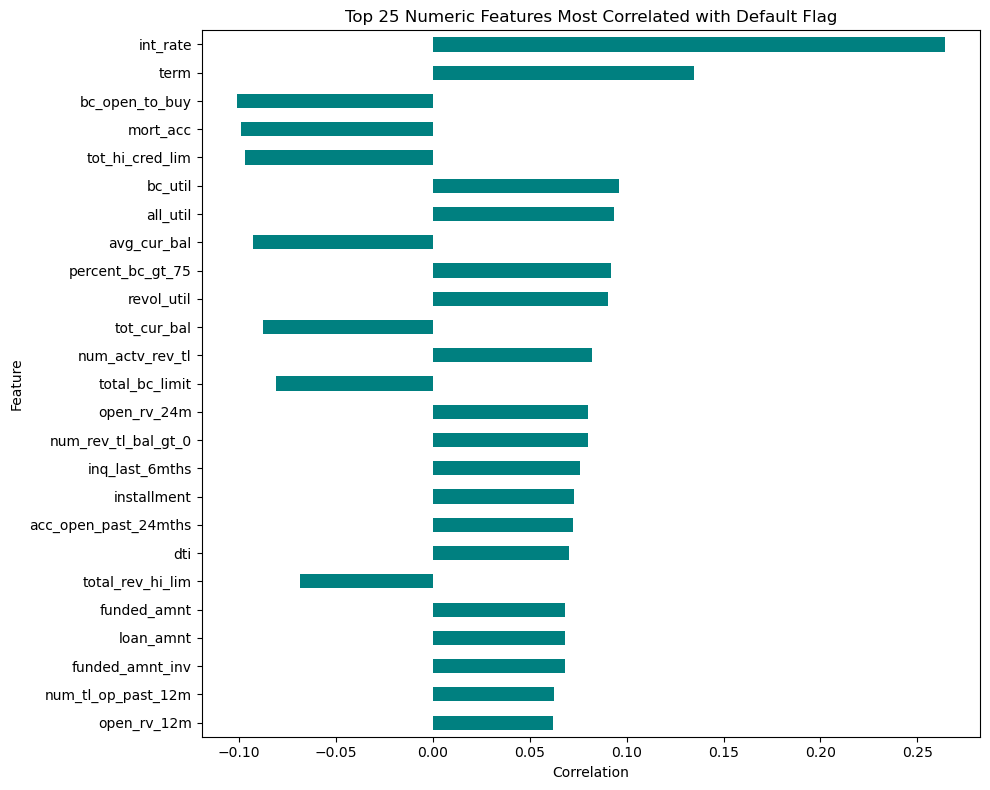

In [ ]:
target = "default_flag" 

corr_with_target = (
    df.corr(numeric_only=True)[target]
    .drop(target)
    .sort_values(key=lambda x: x.abs(), ascending=False)
)

top25 = corr_with_target.head(25)

plt.figure(figsize=(10, 8))
top25.plot(kind="barh", color="teal")
plt.title("Top 25 Numeric Features Most Correlated with Default Flag")
plt.xlabel("Correlation")
plt.ylabel("Feature")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig("../figures/EDA/corr_with_target.png", dpi=300, bbox_inches="tight")
plt.show()


Figure 2: Default rate by loan grade

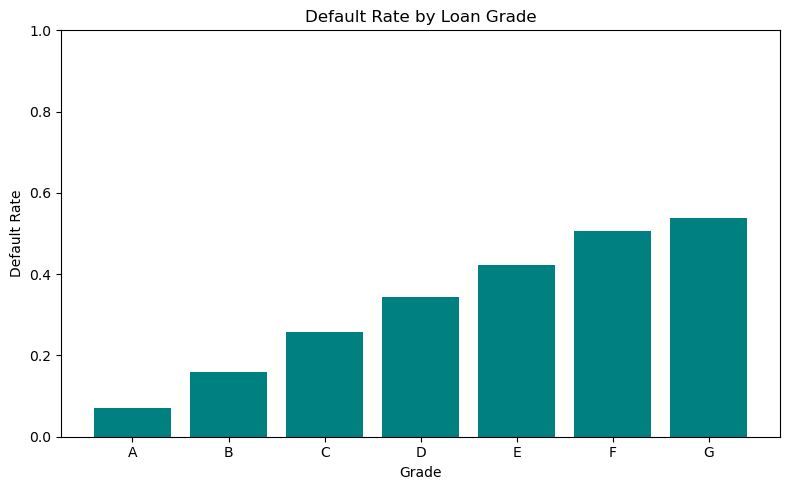

In [16]:
# Reconstruct letter grade from sub_grade
df["grade"] = df["sub_grade"].str[0]

grade_default = (
    df.groupby("grade")[target]
    .mean()
    .reindex(["A","B","C","D","E","F","G"])
)

plt.figure(figsize=(8, 5))
plt.bar(grade_default.index, grade_default.values, color="teal")
plt.title("Default Rate by Loan Grade")
plt.xlabel("Grade")
plt.ylabel("Default Rate")
plt.ylim(0, 1)
plt.tight_layout()
plt.savefig("../figures/EDA/default_by_grade.png", dpi=300, bbox_inches="tight")
plt.show()


Figure 3: Interest rate vs Annual Income by loan grade

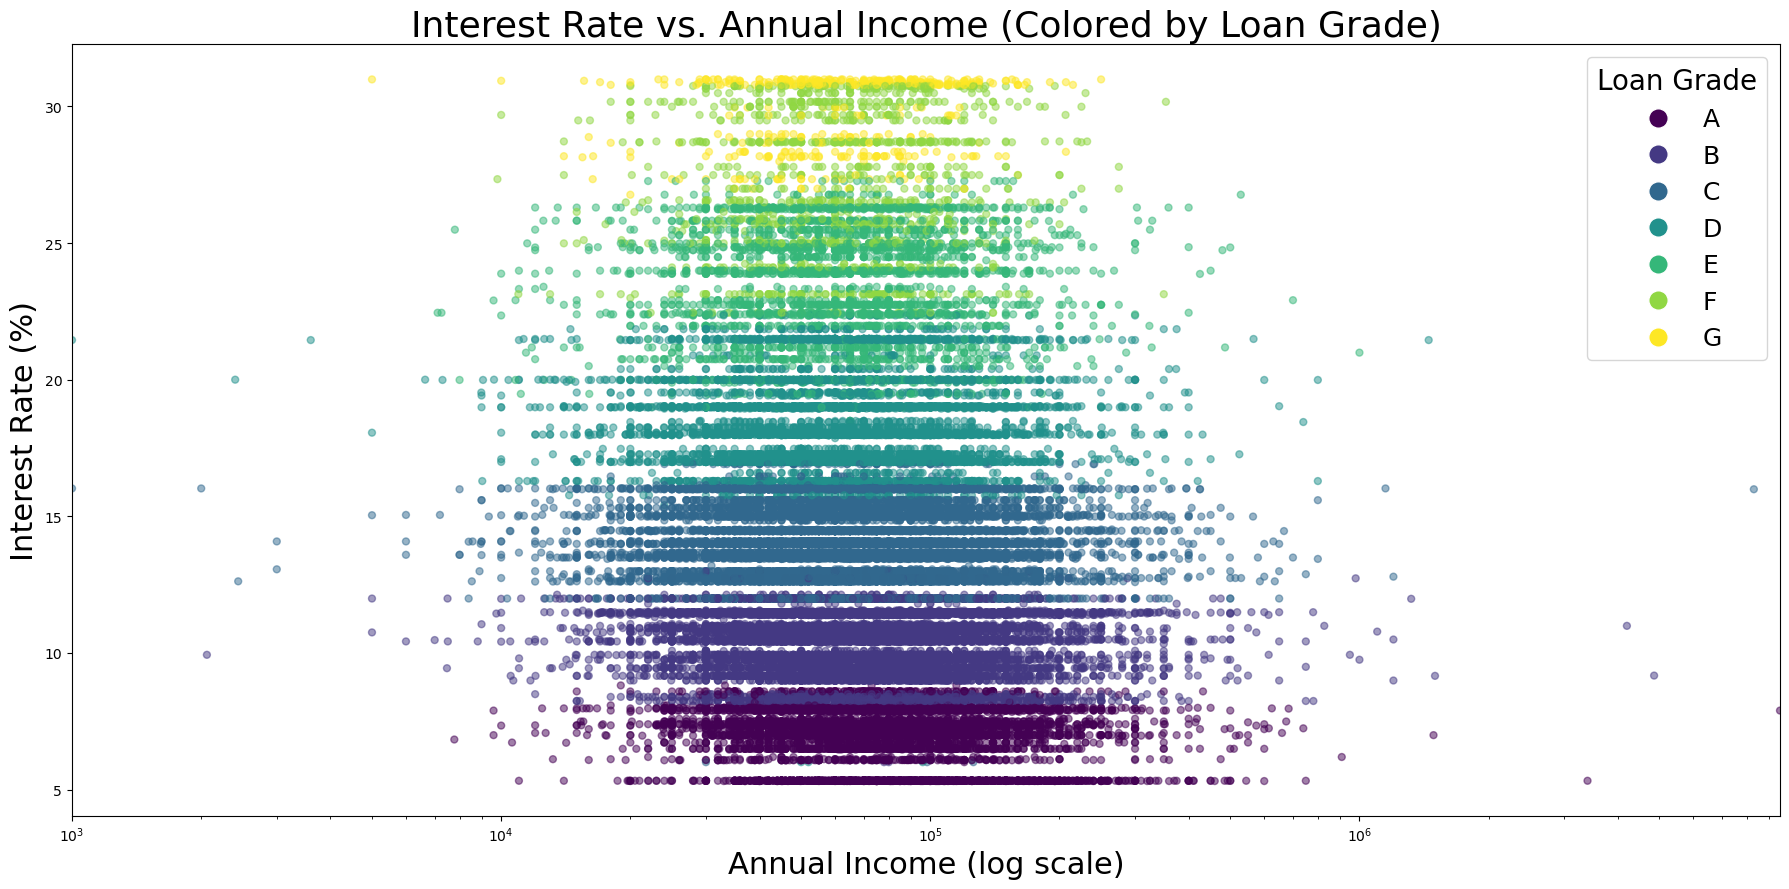

In [20]:
grade_order = ["A", "B", "C", "D", "E", "F", "G"]
grade_to_num = {g: i for i, g in enumerate(grade_order)}
df["grade_num"] = df["grade"].map(grade_to_num)

# Sample for readability
df_sample = df.sample(50000, random_state=42)

plt.figure(figsize=(18, 9))

scatter = plt.scatter(
    df_sample["annual_inc"],
    df_sample["int_rate"],
    c=df_sample["grade_num"],
    cmap="viridis",
    alpha=0.5,
    s=25,
)

plt.xscale("log")
plt.xlim(1e3, df_sample["annual_inc"].max())

plt.xlabel("Annual Income (log scale)", fontsize=22)
plt.ylabel("Interest Rate (%)", fontsize=22)
plt.title("Interest Rate vs. Annual Income (Colored by Loan Grade)", fontsize=26)

from matplotlib.lines import Line2D

legend_handles = [
    Line2D(
        [0], [0],
        marker="o",
        color="w",
        markerfacecolor=plt.cm.viridis(grade_to_num[g] / (len(grade_order) - 1)),
        markersize=14,
        label=g,
    )
    for g in grade_order
]

plt.legend(
    handles=legend_handles,
    title="Loan Grade",
    title_fontsize=20,
    fontsize=18,
    loc="upper right",
)

plt.tight_layout()
plt.savefig("../figures/EDA/interest_vs_income_by_grade.png", dpi=300, bbox_inches="tight")
plt.show()


Figure 4: Interest rate vs annual income by decile

/var/folders/32/vzfl33cx7491zqf3ndd6vxkw0000gn/T/ipykernel_61036/1052731436.py:11: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_heat.groupby(["inc_bin", "amt_bin"])["int_rate"]


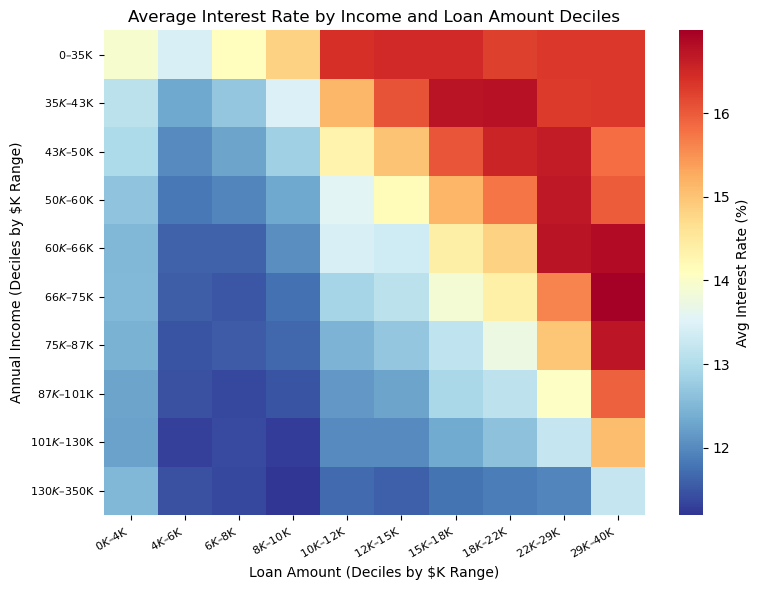

In [22]:
df_heat = df.copy()

upper_cap = df_heat["annual_inc"].quantile(0.995)
df_heat["annual_inc_capped"] = np.minimum(df_heat["annual_inc"], upper_cap)


df_heat["inc_bin"] = pd.qcut(df_heat["annual_inc_capped"], 10)
df_heat["amt_bin"] = pd.qcut(df_heat["loan_amnt"], 10)

pivot = (
    df_heat.groupby(["inc_bin", "amt_bin"])["int_rate"]
    .mean()
    .unstack()
)

def format_bin_labels(bins):
    formatted = []
    for b in bins:
        low = int(b.left // 1000)
        high = int(b.right // 1000)
        formatted.append(f"${low}K–${high}K")
    return formatted

x_labels = format_bin_labels(pivot.columns)
y_labels = format_bin_labels(pivot.index)
y_labels[0] = f"$0–${int(pivot.index[0].right // 1000)}K"

plt.figure(figsize=(8, 6))
sns.heatmap(
    pivot,
    cmap="RdYlBu_r",
    annot=False,
    cbar_kws={"label": "Avg Interest Rate (%)"},
)
plt.xticks(
    ticks=plt.xticks()[0],
    labels=x_labels,
    rotation=30,
    ha="right",
    fontsize=8,
)
plt.yticks(
    ticks=plt.yticks()[0],
    labels=y_labels,
    fontsize=8,
)
plt.title("Average Interest Rate by Income and Loan Amount Deciles")
plt.xlabel("Loan Amount (Deciles by $K Range)")
plt.ylabel("Annual Income (Deciles by $K Range)")
plt.tight_layout()
plt.savefig("../figures/EDA/interest_rate_income_loan_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()


Figure 5: Average Interest Rate by month

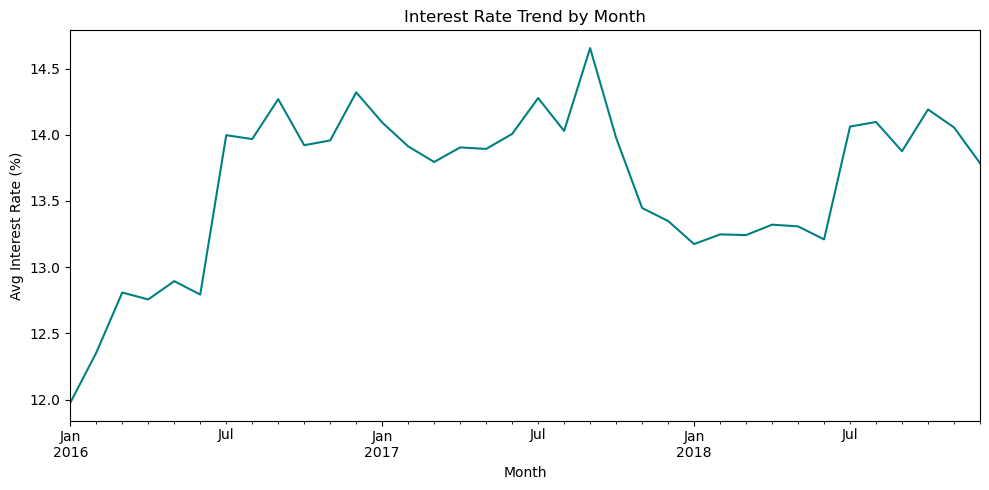

In [28]:
df["issue_month"] = df["issue_d"].dt.to_period("M")
monthly_ir = df.groupby("issue_month")["int_rate"].mean()

plt.figure(figsize=(10,5))
monthly_ir.plot(color="teal")
plt.title("Interest Rate Trend by Month")
plt.xlabel("Month")
plt.ylabel("Avg Interest Rate (%)")
plt.tight_layout()
plt.savefig("../figures/EDA/interest_rate_by_month.png", dpi=300)
plt.show()
